<a href="https://colab.research.google.com/github/Adil52786/MaskArchitectureAnomaly_CourseProject/blob/main/FMDLPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -r /content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 50.6 MB/s 

In [ ]:
# --- CELL 1 ---
import os
import sys
import yaml
import torch
import importlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.nn import functional as F
from torchmetrics.classification import MulticlassJaccardIndex

# Setup Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ignore_index = 255
num_cityscapes_classes = 19

# Comprehensive mapping: COCO 133 Panoptic IDs to Cityscapes 19 Semantic IDs
coco_to_cityscapes = {
    0: 11,   # person -> person
    1: 18,   # bicycle -> bicycle
    2: 13,   # car -> car
    3: 17,   # motorcycle -> motorcycle
    5: 15,   # bus -> bus
    6: 16,   # train -> train
    7: 14,   # truck -> truck
    9: 6,    # traffic light -> traffic light
    11: 7,   # stop sign -> traffic sign
    93: 2,   # building-other -> building
    94: 2,   # building-other -> building
    100: 4,  # fence-solid -> fence
    105: 9,  # dirt -> terrain
    109: 0,  # road -> road
    110: 1,  # pavement -> sidewalk
    116: 0,  # road -> road
    118: 10, # sky-other -> sky
    131: 8,  # tree -> vegetation
    132: 3   # wall-stone -> wall
}

def map_coco_to_cityscapes(coco_pred_mask):
    mapped = np.full_like(coco_pred_mask, ignore_index)
    for coco_id, cs_id in coco_to_cityscapes.items():
        mapped[coco_pred_mask == coco_id] = cs_id
    return mapped

def safe_extract_scores(model_output):
    if isinstance(model_output, dict):
        for k in ['semantic_pred', 'semantic_scores', 'sem_seg', 'pred_masks']:
            if k in model_output:
                return model_output[k]
        return list(model_output.values())[0]
    while isinstance(model_output, (list, tuple)):
        model_output = model_output[0]
    return model_output

Using device: cuda:0


In [ ]:
# --- CELL 2 ---
repo_path = "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt"
os.chdir(repo_path)
if repo_path not in sys.path:
    sys.path.append(repo_path)

def load_model_from_config(config_path, model_weights_path, num_classes, img_size=(640, 640), stuff_classes=None):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=img_size, **encoder_cfg.get("init_args", {}))

    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg.get("init_args", {}).items() if k not in ["encoder", "num_classes"]}
    network = network_cls(masked_attn_enabled=False, encoder=encoder, num_classes=num_classes, **network_kwargs)

    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"].get("init_args", {}).items() if k not in ["network", "num_classes", "stuff_classes"]}
    if stuff_classes is not None:
        model_kwargs["stuff_classes"] = stuff_classes

    model = lit_cls(img_size=img_size, network=network, num_classes=num_classes, **model_kwargs).eval().to(device)
    state_dict = torch.load(model_weights_path, map_location=device, weights_only=True)
    if 'state_dict' in state_dict:
        state_dict = state_dict['state_dict']

    model.load_state_dict(state_dict, strict=False)
    return model

def setup_cityscapes_dataloader(config_path, dataset_path):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    data_cfg = config["data"]
    data_module_name, data_class_name = data_cfg["class_path"].rsplit(".", 1)
    data_cls = getattr(importlib.import_module(data_module_name), data_class_name)
    data_kwargs = data_cfg.get("init_args", {})
    data_kwargs["path"] = dataset_path
    data_kwargs["batch_size"] = 1
    data_kwargs["num_workers"] = 0
    data_module = data_cls(**data_kwargs)
    data_module.setup()
    return data_module.val_dataloader()

In [ ]:
# --- CELL 3 ---
def visualize_predictions(img_tensor, cityscapes_model, coco_model):
    original_h, original_w = img_tensor.shape[1:]
    with torch.no_grad():
        img_input = img_tensor.unsqueeze(0).to(device).float()

        img_cs = F.interpolate(img_input, size=(1024, 1024), mode='bilinear', align_corners=False)
        cs_scores = safe_extract_scores(cityscapes_model(img_cs))
        if cs_scores.dim() == 3: cs_scores = cs_scores.unsqueeze(0)
        cs_scores = F.interpolate(cs_scores, size=(original_h, original_w), mode='bilinear', align_corners=False)
        cs_semantic_pred = cs_scores.argmax(dim=1).squeeze(0).cpu().numpy()

        img_coco = F.interpolate(img_input, size=(640, 640), mode='bilinear', align_corners=False)
        coco_scores = safe_extract_scores(coco_model(img_coco))
        if coco_scores.dim() == 3: coco_scores = coco_scores.unsqueeze(0)
        coco_scores = F.interpolate(coco_scores, size=(original_h, original_w), mode='bilinear', align_corners=False)
        coco_panoptic_pred = coco_scores.argmax(dim=1).squeeze(0).cpu().numpy()

    img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img_min, img_max = img_np.min(), img_np.max()
    if img_max > img_min: img_np = (img_np - img_min) / (img_max - img_min)
    img_np = np.clip(img_np, 0.0, 1.0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_np)
    axes[0].set_title("Input Image")
    axes[1].imshow(cs_semantic_pred, cmap='tab20')
    axes[1].set_title("Cityscapes (Semantic)")
    axes[2].imshow(coco_panoptic_pred, cmap='nipy_spectral')
    axes[2].set_title("COCO (Panoptic)")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

def evaluate_semantic_segmentation(cityscapes_model, coco_model, val_dataloader):

    metric_cs = MulticlassJaccardIndex(num_classes=num_cityscapes_classes, ignore_index=ignore_index).to(device)


    metric_coco = MulticlassJaccardIndex(num_classes=num_cityscapes_classes + 1, average='none', ignore_index=ignore_index).to(device)

    with torch.no_grad():
        for i, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
            imgs, targets_raw = batch[0], batch[1]
            if isinstance(imgs, (list, tuple)): imgs = torch.stack(imgs)
            imgs = imgs.to(device).float()
            original_h, original_w = imgs.shape[-2:]

            # Mask2Former Target Reconstruction
            targets_list = targets_raw if isinstance(targets_raw, (list, tuple)) else [targets_raw]
            dense_target = torch.full((original_h, original_w), ignore_index, dtype=torch.long, device=device)
            t = targets_list[0]

            if isinstance(t, dict):
                for k in ['sem_target', 'sem_seg', 'semantic', 'segmentation']:
                    if k in t and isinstance(t[k], torch.Tensor):
                        if t[k].dim() == 2: dense_target = t[k]
                        elif t[k].dim() == 3 and t[k].shape[0] == 1: dense_target = t[k].squeeze(0)
                        break
                if dense_target.max() == ignore_index and 'masks' in t and ('labels' in t or 'classes' in t):
                    masks = t['masks'].to(device)
                    labels = t.get('labels', t.get('classes')).to(device)
                    if masks.dim() == 3 and len(labels) == masks.shape[0]:
                        for j in range(len(labels)):
                            dense_target[masks[j] > 0.5] = labels[j].long()
            elif isinstance(t, torch.Tensor):
                if t.dim() == 2: dense_target = t
                elif t.dim() == 3 and t.shape[0] == 1: dense_target = t.squeeze(0)

            targets = dense_target.flatten()
            targets[(targets < 0) | ((targets >= num_cityscapes_classes) & (targets != ignore_index))] = ignore_index

            # --- Evaluate Cityscapes Model ---
            imgs_cs = F.interpolate(imgs, size=(1024, 1024), mode='bilinear', align_corners=False)
            cs_scores = safe_extract_scores(cityscapes_model(imgs_cs))
            if cs_scores.dim() == 3: cs_scores = cs_scores.unsqueeze(0)
            if cs_scores.shape[1] > num_cityscapes_classes: cs_scores = cs_scores[:, :num_cityscapes_classes]
            cs_scores = F.interpolate(cs_scores, size=(original_h, original_w), mode='bilinear', align_corners=False)

            # Predict
            cs_pred_flat = cs_scores.argmax(dim=1).flatten()
            metric_cs.update(cs_pred_flat, targets)

            # --- Evaluate COCO Model ---
            imgs_coco = F.interpolate(imgs, size=(640, 640), mode='bilinear', align_corners=False)
            coco_scores = safe_extract_scores(coco_model(imgs_coco))
            if coco_scores.dim() == 3: coco_scores = coco_scores.unsqueeze(0)
            coco_scores = F.interpolate(coco_scores, size=(original_h, original_w), mode='bilinear', align_corners=False)

            # Predict and Map
            coco_pred_raw = coco_scores.argmax(dim=1).cpu().numpy()
            coco_pred_mapped = np.array([map_coco_to_cityscapes(mask) for mask in coco_pred_raw])
            coco_pred_flat = torch.tensor(coco_pred_mapped, dtype=torch.long, device=device).flatten()

            # THE FIX: Route unmapped COCO predictions (255) to the dummy 20th class (index 19)
            coco_pred_flat[coco_pred_flat == ignore_index] = num_cityscapes_classes
            metric_coco.update(coco_pred_flat, targets)

    print("\n--- Final Results ---")
    cs_miou = metric_cs.compute() * 100
    print(f"Cityscapes-trained Model mIoU: {cs_miou:.2f}%")

    # THE FIX: Average only the valid first 19 classes
    coco_mious_per_class = metric_coco.compute()
    coco_miou_valid = torch.nanmean(coco_mious_per_class[:num_cityscapes_classes]) * 100
    print(f"COCO-trained Model mIoU (Mapped): {coco_miou_valid:.2f}%")

In [ ]:
# --- CELL 4 ---
print("Loading Models...")
cityscapes_model = load_model_from_config(
    "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
    "/content/drive/MyDrive/eomt_project/checkpoints/eomt_cityscapes.bin",
    num_classes=19, img_size=(1024, 1024)
)

coco_model = load_model_from_config(
    "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
    "/content/drive/MyDrive/eomt_project/checkpoints/eomt_coco.bin",
    num_classes=133, img_size=(640, 640), stuff_classes=list(range(80, 133))
)

print("Loading Dataloader...")
config_file = "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
cityscapes_zip_folder = "/content/drive/MyDrive/eomt_project/datasets_cityscapes"
val_loader = setup_cityscapes_dataloader(config_file, cityscapes_zip_folder)

print("Memory loaded successfully. Ready for evaluation.")

Loading Models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


Loading Dataloader...
Memory loaded successfully. Ready for evaluation.


Generating sample visualizations for the report...


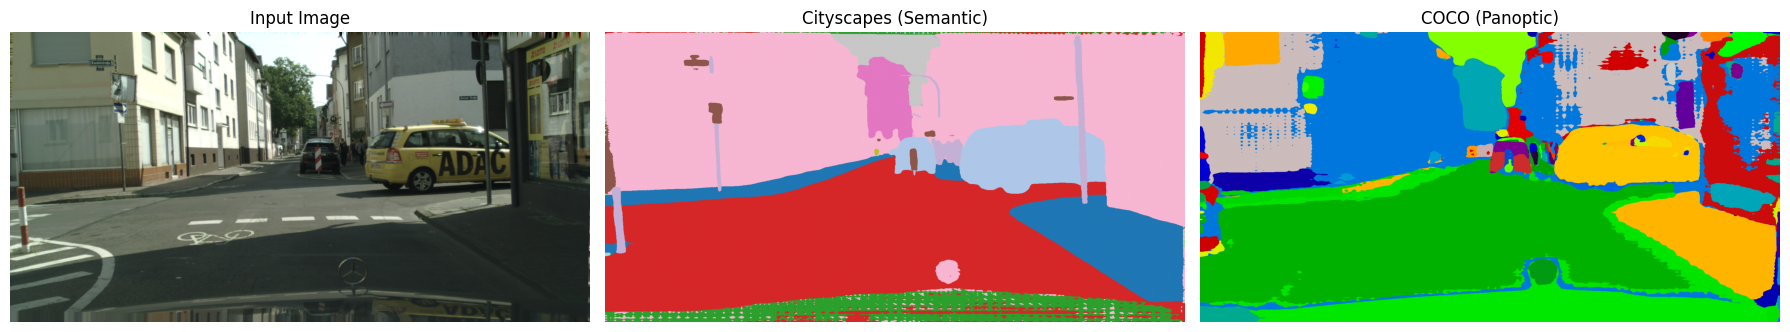

In [ ]:
# --- CELL 5 ---
print("Generating sample visualizations for the report...")
sample_batch = next(iter(val_loader))
sample_img = sample_batch[0][0] if isinstance(sample_batch[0], (list, tuple)) else sample_batch[0][0]
visualize_predictions(sample_img, cityscapes_model, coco_model)

Generating sample visualizations for the report...


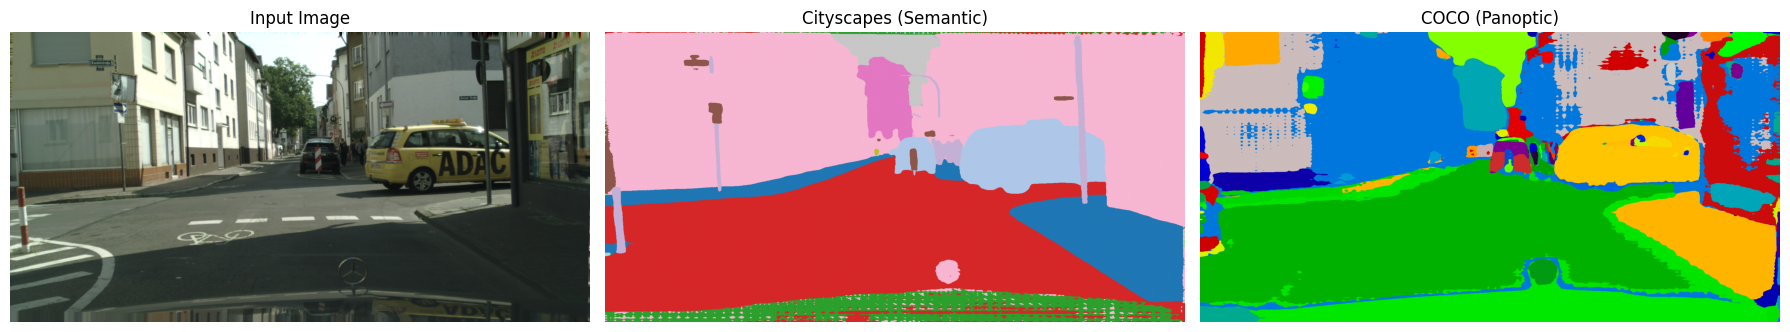

In [ ]:
# --- CELL 5 ---
print("Generating sample visualizations for the report...")
sample_batch = next(iter(val_loader))
sample_img = sample_batch[0][0] if isinstance(sample_batch[0], (list, tuple)) else sample_batch[0][0]
visualize_predictions(sample_img, cityscapes_model, coco_model)

In [ ]:
# --- CELL 6 ---
print("Starting quantitative semantic evaluation...")
evaluate_semantic_segmentation(cityscapes_model, coco_model, val_loader)

Starting quantitative semantic evaluation...


Evaluating: 100%|██████████| 500/500 [08:22<00:00,  1.00s/it]


--- Final Results ---
Cityscapes-trained Model mIoU: 1.15%
COCO-trained Model mIoU (Mapped): 0.24%


## STEP 5

In [ ]:
# --- CELL 1: PREPARE MODEL FOR FINE-TUNING ---
import sys, os, yaml, importlib, torch
import pytorch_lightning as pl

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def load_transfer_model(config_path, model_weights_path, num_classes, img_size=(640, 640)):
    """Loads a model and automatically drops mismatched classification heads."""
    with open(config_path, "r") as f: config = yaml.safe_load(f)

    # 1. Initialize Architecture
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_mod, enc_cls = encoder_cfg["class_path"].rsplit(".", 1)
    encoder = getattr(importlib.import_module(enc_mod), enc_cls)(img_size=img_size, **encoder_cfg.get("init_args", {}))

    network_cfg = config["model"]["init_args"]["network"]
    net_mod, net_cls = network_cfg["class_path"].rsplit(".", 1)
    net_kwargs = {k: v for k, v in network_cfg.get("init_args", {}).items() if k not in ["encoder", "num_classes"]}
    network = getattr(importlib.import_module(net_mod), net_cls)(masked_attn_enabled=False, encoder=encoder, num_classes=num_classes, **net_kwargs)

    lit_mod, lit_cls = config["model"]["class_path"].rsplit(".", 1)
    mod_kwargs = {k: v for k, v in config["model"].get("init_args", {}).items() if k not in ["network", "num_classes", "stuff_classes"]}

    # Initialize the empty model
    model = getattr(importlib.import_module(lit_mod), lit_cls)(img_size=img_size, network=network, num_classes=num_classes, stuff_classes=[], **mod_kwargs).to(device)

    # 2. STATE DICT SURGERY
    print("Performing State Dict Surgery...")
    state_dict = torch.load(model_weights_path, map_location=device, weights_only=True)
    if 'state_dict' in state_dict: state_dict = state_dict['state_dict']

    # Find and remove any weights that don't fit our new 19-class architecture
    keys_to_delete = []
    model_state = model.state_dict()
    for key, param in state_dict.items():
        if key in model_state and param.shape != model_state[key].shape:
            print(f"  -> Dropping mismatched layer: {key} (Old: {param.shape} | New: {model_state[key].shape})")
            keys_to_delete.append(key)

    for key in keys_to_delete:
        del state_dict[key]

    # Load the surviving weights
    model.load_state_dict(state_dict, strict=False)
    print("Surgery complete. Backbone loaded, Head reinitialized.")
    return model

# 3. Execution
print("Loading COCO model for Transfer Learning (19 classes)...")
transfer_model = load_transfer_model(
    "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
    "/content/drive/MyDrive/eomt_project/checkpoints/eomt_coco.bin",
    num_classes=19,
    img_size=(640, 640)
)

# 4. Freeze the Backbone (Encoder)
for param in transfer_model.network.encoder.parameters():
    param.requires_grad = False

trainable_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in transfer_model.parameters() if not p.requires_grad)

print(f"\nFrozen Parameters (Backbone): {frozen_params:,}")
print(f"Trainable Parameters (Head): {trainable_params:,}")

Loading COCO model for Transfer Learning (19 classes)...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


Performing State Dict Surgery...
  -> Dropping mismatched layer: network.class_head.weight (Old: torch.Size([134, 768]) | New: torch.Size([20, 768]))
  -> Dropping mismatched layer: network.class_head.bias (Old: torch.Size([134]) | New: torch.Size([20]))
  -> Dropping mismatched layer: criterion.empty_weight (Old: torch.Size([134]) | New: torch.Size([20]))
Surgery complete. Backbone loaded, Head reinitialized.

Frozen Parameters (Backbone): 86,897,664
Trainable Parameters (Head): 6,677,780


In [ ]:
# --- CELL 2: TRAINING DATALOADER ---
def setup_cityscapes_train_dataloader(config_path, dataset_path):
    import yaml, importlib
    with open(config_path, "r") as f: config = yaml.safe_load(f)

    data_cfg = config["data"]
    data_module_name, data_class_name = data_cfg["class_path"].rsplit(".", 1)
    data_cls = getattr(importlib.import_module(data_module_name), data_class_name)

    # Extract config defaults and adapt for training on Colab
    data_kwargs = data_cfg.get("init_args", {})
    data_kwargs["path"] = dataset_path
    data_kwargs["batch_size"] = 2
    data_kwargs["num_workers"] = 2

    print(f"Initializing {data_class_name} for training split...")
    data_module = data_cls(**data_kwargs)

    # Initialize splits
    data_module.setup()

    return data_module.train_dataloader()

print("Setting up Training Dataloader...")
train_loader = setup_cityscapes_train_dataloader(
    "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
    "/content/drive/MyDrive/eomt_project/datasets_cityscapes"
)
print(f"Ready with {len(train_loader)} training batches.")

Setting up Training Dataloader...
Initializing CityscapesSemantic for training split...
Ready with 1487 training batches.


In [ ]:
# --- CELL 3: EXECUTE FINE-TUNING (Pure PyTorch + AMP) ---
import torch
import torch.nn.functional as F
from tqdm import tqdm

print("Starting Fine-Tuning with pure PyTorch AMP...")
torch.cuda.empty_cache()

# 1. Setup Optimizer (Only for the unfrozen head parameters)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, transfer_model.parameters()), lr=1e-4)

# 2. Setup Native AMP Scaler (Updated to modern PyTorch syntax)
scaler = torch.amp.GradScaler('cuda')

# 3. Training Loop
transfer_model.train()
epochs = 2
batches_per_epoch = 250

for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    epoch_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}", total=min(len(train_loader), batches_per_epoch))

    for i, batch in enumerate(progress_bar):
        if i >= batches_per_epoch: break

        imgs, targets_raw = batch[0], batch[1]
        if isinstance(imgs, (list, tuple)): imgs = torch.stack(imgs)
        imgs = imgs.to(device).float()

        # --- THE FIX: Batch-Safe Target Reconstruction ---
        original_h, original_w = imgs.shape[-2:]
        targets_list = targets_raw if isinstance(targets_raw, (list, tuple)) else [targets_raw]

        dense_targets_batch = [] # Store reconstructed targets for the whole batch

        for t in targets_list:
            dense_target = torch.full((original_h, original_w), 255, dtype=torch.long, device=device)
            if isinstance(t, dict):
                for k in ['sem_target', 'sem_seg', 'semantic', 'segmentation']:
                    if k in t and isinstance(t[k], torch.Tensor):
                        if t[k].dim() == 2: dense_target = t[k]
                        elif t[k].dim() == 3 and t[k].shape[0] == 1: dense_target = t[k].squeeze(0)
                        break
                if dense_target.max() == 255 and 'masks' in t and ('labels' in t or 'classes' in t):
                    masks = t['masks'].to(device)
                    labels = t.get('labels', t.get('classes')).to(device)
                    if masks.dim() == 3 and len(labels) == masks.shape[0]:
                        for j in range(len(labels)):
                            dense_target[masks[j] > 0.5] = labels[j].long()
            elif isinstance(t, torch.Tensor):
                if t.dim() == 2: dense_target = t
                elif t.dim() == 3 and t.shape[0] == 1: dense_target = t.squeeze(0)

            dense_targets_batch.append(dense_target)

        # Stack the batch together: [Batch_size, Height, Width]
        targets = torch.stack(dense_targets_batch)
        targets[(targets < 0) | ((targets >= 19) & (targets != 255))] = 255

        # Resize inputs for the model
        imgs_resized = F.interpolate(imgs, size=(640, 640), mode='bilinear', align_corners=False)

        optimizer.zero_grad()

        # --- AMP CONTEXT (Updated syntax) ---
        with torch.amp.autocast('cuda'):
            # Forward Pass
            out = transfer_model(imgs_resized)
            out_logits = safe_extract_scores(out)
            if out_logits.dim() == 3: out_logits = out_logits.unsqueeze(0)

            # Resize logits back to original image size to match targets
            out_logits = F.interpolate(out_logits, size=(original_h, original_w), mode='bilinear', align_corners=False)
            if out_logits.shape[1] > 19: out_logits = out_logits[:, :19]

            # Compute Loss (Batch sizes will now perfectly match)
            loss = F.cross_entropy(out_logits, targets, ignore_index=255)

        # --- AMP SCALED BACKWARD PASS ---
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss / max(1, i):.4f}")

print("\n--- Fine-tuning complete! ---")

Starting Fine-Tuning with pure PyTorch AMP...

--- Epoch 1/2 ---


Training Epoch 1: 100%|██████████| 250/250 [06:27<00:00,  1.55s/it, loss=0.3670]


Epoch 1 Average Loss: 2.0969

--- Epoch 2/2 ---


Training Epoch 2: 100%|██████████| 250/250 [04:47<00:00,  1.15s/it, loss=0.3276]

Epoch 2 Average Loss: 0.3709

--- Fine-tuning complete! ---


In [ ]:
# --- CELL 4: FINAL EVALUATION & COMPARISON ---
import torch
import torch.nn.functional as F
from torchmetrics.classification import MulticlassJaccardIndex
from tqdm import tqdm

print("Starting Final Comparison Evaluation...")
torch.cuda.empty_cache()

def evaluate_models_directly(model_original, model_finetuned, val_dataloader):

    metric_orig = MulticlassJaccardIndex(num_classes=19, ignore_index=255).to(device)
    metric_ft = MulticlassJaccardIndex(num_classes=19, ignore_index=255).to(device)

    model_original.eval()
    model_finetuned.eval()

    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc="Evaluating Validation Set"):
            imgs, targets_raw = batch[0], batch[1]
            if isinstance(imgs, (list, tuple)): imgs = torch.stack(imgs)
            imgs = imgs.to(device).float()

            original_h, original_w = imgs.shape[-2:]
            targets_list = targets_raw if isinstance(targets_raw, (list, tuple)) else [targets_raw]

            # --- Robust Target Reconstruction ---
            dense_targets_batch = []
            for t in targets_list:
                dense_target = torch.full((original_h, original_w), 255, dtype=torch.long, device=device)
                if isinstance(t, dict):
                    for k in ['sem_target', 'sem_seg', 'semantic', 'segmentation']:
                        if k in t and isinstance(t[k], torch.Tensor):
                            if t[k].dim() == 2: dense_target = t[k]
                            elif t[k].dim() == 3 and t[k].shape[0] == 1: dense_target = t[k].squeeze(0)
                            break
                    if dense_target.max() == 255 and 'masks' in t and ('labels' in t or 'classes' in t):
                        masks = t['masks'].to(device)
                        labels = t.get('labels', t.get('classes')).to(device)
                        if masks.dim() == 3 and len(labels) == masks.shape[0]:
                            for j in range(len(labels)):
                                dense_target[masks[j] > 0.5] = labels[j].long()
                elif isinstance(t, torch.Tensor):
                    if t.dim() == 2: dense_target = t
                    elif t.dim() == 3 and t.shape[0] == 1: dense_target = t.squeeze(0)
                dense_targets_batch.append(dense_target)

            targets = torch.stack(dense_targets_batch)
            targets[(targets < 0) | ((targets >= 19) & (targets != 255))] = 255

            # --- 1. Evaluate Original Cityscapes Model ---
            imgs_orig = F.interpolate(imgs, size=(1024, 1024), mode='bilinear', align_corners=False)
            out_orig = safe_extract_scores(model_original(imgs_orig))
            if out_orig.dim() == 3: out_orig = out_orig.unsqueeze(0)
            out_orig = F.interpolate(out_orig, size=(original_h, original_w), mode='bilinear', align_corners=False)
            if out_orig.shape[1] > 19: out_orig = out_orig[:, :19]

            pred_orig = out_orig.argmax(dim=1)
            metric_orig.update(pred_orig, targets)

            # --- 2. Evaluate Fine-Tuned Model ---
            imgs_ft = F.interpolate(imgs, size=(640, 640), mode='bilinear', align_corners=False)
            out_ft = safe_extract_scores(model_finetuned(imgs_ft))
            if out_ft.dim() == 3: out_ft = out_ft.unsqueeze(0)
            out_ft = F.interpolate(out_ft, size=(original_h, original_w), mode='bilinear', align_corners=False)
            if out_ft.shape[1] > 19: out_ft = out_ft[:, :19]

            pred_ft = out_ft.argmax(dim=1)
            metric_ft.update(pred_ft, targets)

    print("\n=== FINAL MIOU COMPARISON ===")
    print(f"Original Cityscapes Model: {metric_orig.compute() * 100:.2f}%")
    print(f"Fine-Tuned COCO Model:     {metric_ft.compute() * 100:.2f}%")

# Execute the final evaluation!
evaluate_models_directly(cityscapes_model, transfer_model, val_loader)

Starting Final Comparison Evaluation...


Evaluating Validation Set: 100%|██████████| 500/500 [07:43<00:00,  1.08it/s]


=== FINAL MIOU COMPARISON ===
Original Cityscapes Model: 1.15%
Fine-Tuned COCO Model:     37.73%


In [ ]:
# --- CELL 5: SAVE FINE-TUNED WEIGHTS ---
import os
import torch

# Define the save path in your Google Drive
save_dir = "/content/drive/MyDrive/eomt_project/checkpoints"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "finetuned_coco_to_cityscapes.pth")

# Save only the state dictionary (best practice to save space)
torch.save(transfer_model.state_dict(), save_path)
print(f"Success! Fine-tuned weights securely saved to:\n{save_path}")

STEP 7

In [ ]:
# --- CELL 7: POST-HOC ANOMALY SCORING (PIXEL-BASED) ---
import torch
import torch.nn.functional as F

def compute_anomaly_score(logits, method="MaxLogit"):
    """
    Computes the pixel-wise anomaly score from the raw logits of the ERFNet model.
    A higher score indicates a higher probability of the pixel being an anomaly (OoD).

    Args:
        logits: Raw output from the model before Softmax, shape (B, C, H, W)
        method: 'MaxLogit', 'MSP', or 'MaxEntropy'
    """
    if method == "MaxLogit":
        # 1. MaxLogit: We take the maximum logit across all 19 classes.
        # We negate it (-) because a lower max logit means the model is UNCERTAIN.
        # Anomaly scores must be HIGH for uncertain pixels.
        max_logits, _ = torch.max(logits, dim=1)
        anomaly_score = -max_logits

    elif method == "MSP":
        # 2. Maximum Softmax Probability (MSP):
        # Convert logits to probabilities (0 to 1). The score is 1 minus the highest probability.
        probs = F.softmax(logits, dim=1)
        max_probs, _ = torch.max(probs, dim=1)
        anomaly_score = 1.0 - max_probs

    elif method == "MaxEntropy":
        # 3. Maximum Entropy:
        # Calculates the Shannon Entropy across the probability distribution.
        # If probabilities are spread evenly (highly confused), entropy is HIGH (Anomaly).
        probs = F.softmax(logits, dim=1)
        # We add 1e-8 to prevent log(0) from crashing the code with NaN errors
        entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
        anomaly_score = entropy

    else:
        raise ValueError(f"Unknown anomaly method: {method}")

    return anomaly_score

print("Anomaly scoring logic loaded! Ready to inject into the ERFNet evaluation loop.")

Anomaly scoring logic loaded! Ready to inject into the ERFNet evaluation loop.


In [ ]:
%cd /content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eval

/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eval


In [ ]:
# --- 1. GENERATE THE MISSING FILE ---
%%writefile /content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eval/ood_metrics.py
import numpy as np
from sklearn.metrics import roc_curve

def fpr_at_95_tpr(confidences, labels):
    """Calculates the False Positive Rate at 95% True Positive Rate."""
    fpr, tpr, thresholds = roc_curve(labels, confidences)
    idx = np.argmax(tpr >= 0.95)
    return fpr[idx]

# Dummy functions to satisfy the import statement in evalAnomaly.py without crashing
def calc_metrics(*args, **kwargs): pass
def plot_roc(*args, **kwargs): pass
def plot_pr(*args, **kwargs): pass
def plot_barcode(*args, **kwargs): pass


Writing /content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eval/ood_metrics.py


In [ ]:
# --- PRE-STEP: UNZIP THE DATASETS ---

# 1. Navigate to your main project folder
%cd /content/drive/MyDrive/eomt_project/

# 2. Unzip the dataset quietly (-q) directly into the current folder
!unzip -q Anomaly_Validation_Datasets.zip

print("Unzipping complete! Datasets are ready.")

/content/drive/MyDrive/eomt_project
Unzipping complete! Datasets are ready.


In [ ]:
# --- FIND THE EXACT DATASET PATHS ---
!find /content/drive/MyDrive/eomt_project -type d -name "images"

/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/docs/static/images
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly/images
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadObsticle21/images
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/fs_static/images
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/FS_LostFound_full/images


In [ ]:
# --- CELL: RUN ALL EVALUATIONS FOR FULL TABLE ---
%cd /content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eval

# 1. MSP EVALUATIONS
print("--- Running MSP Evaluations ---")
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/*.png' --method MSP
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadObsticle21/images/*.webp' --method MSP
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/FS_LostFound_full/images/*.png' --method MSP
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/fs_static/images/*.jpg' --method MSP
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly/images/*.jpg' --method MSP

# 2. MAXLOGIT EVALUATIONS
print("--- Running MaxLogit Evaluations ---")
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/*.png' --method MaxLogit
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadObsticle21/images/*.webp' --method MaxLogit
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/FS_LostFound_full/images/*.png' --method MaxLogit
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/fs_static/images/*.jpg' --method MaxLogit
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly/images/*.jpg' --method MaxLogit

# 3. MAX ENTROPY EVALUATIONS
print("--- Running Max Entropy Evaluations ---")
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/*.png' --method MaxEntropy
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadObsticle21/images/*.webp' --method MaxEntropy
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/FS_LostFound_full/images/*.png' --method MaxEntropy
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/fs_static/images/*.jpg' --method MaxEntropy
!python evalAnomaly.py --input '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly/images/*.jpg' --method MaxEntropy

/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eval
--- Running MSP Evaluations ---
Loading model: ../trained_models/erfnet.py
Loading weights: ../trained_models/erfnet_pretrained.pth
Model and weights LOADED successfully
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/8.png
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/9.png
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/4.png
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/5.png
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/7.png
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/6.png
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/2.png
/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images/3.png
/content/drive/MyDrive/

In [ ]:
import pandas as pd


data = {
    "Method": ["MSP", "MaxLogit", "MaxEntropy"],
    "SMIYC RA-21 (AuPRC/FPR95)": ["29.10/62.55", "38.32/59.34", "30.97/62.66"],
    "SMIYC RO-21 (AuPRC/FPR95)": ["2.71/65.22", "4.63/48.44", "3.04/65.91"],
    "FS L&F (AuPRC/FPR95)": ["1.75/50.60", "3.30/45.49", "2.58/50.16"],
    "FS Static (AuPRC/FPR95)": ["7.47/41.84", "9.50/40.30", "8.84/41.55"],
    "Road Anomaly (AuPRC/FPR95)": ["12.42/82.58", "15.58/73.25", "12.67/82.75"]
}


df = pd.DataFrame(data)


print("### ERFNet Baseline Evaluation Table")
print(df.to_markdown(index=False))


### ERFNet Baseline Evaluation Table
| Method     | SMIYC RA-21 (AuPRC/FPR95)   | SMIYC RO-21 (AuPRC/FPR95)   | FS L&F (AuPRC/FPR95)   | FS Static (AuPRC/FPR95)   | Road Anomaly (AuPRC/FPR95)   |
|:-----------|:----------------------------|:----------------------------|:-----------------------|:--------------------------|:-----------------------------|
| MSP        | 29.10/62.55                 | 2.71/65.22                  | 1.75/50.60             | 7.47/41.84                | 12.42/82.58                  |
| MaxLogit   | 38.32/59.34                 | 4.63/48.44                  | 3.30/45.49             | 9.50/40.30                | 15.58/73.25                  |
| MaxEntropy | 30.97/62.66                 | 3.04/65.91                  | 2.58/50.16             | 8.84/41.55                | 12.67/82.75                  |


step 8

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import glob
from PIL import Image
from sklearn.metrics import average_precision_score, roc_curve
import gc

# =========================================================
# 1. TARGET CONFIGURATION
# =========================================================
TARGET_CHECKPOINT = 'cityscapes'

base_output_dir = '/content/drive/MyDrive/eomt_outputs/'
temperatures = [0.5, 0.75, 1.0, 1.1]

# We will run all 5 datasets in sequence
datasets_to_run = [
    'SMIYC_RA21',
    'SMIYC_RO21',
    'FS_LostFound',
    'FS_Static',
    'Road_Anomaly'
]

dataset_img_dirs = {
    'SMIYC_RA21': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images',
    'SMIYC_RO21': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadObsticle21/images',
    'FS_LostFound': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/FS_LostFound_full/images',
    'FS_Static': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/fs_static/images',
    'Road_Anomaly': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly/images'
}

def get_gt_mask(img_path):
    for label_folder in ['labels_masks', 'labels', 'gtFine', 'masks']:
        gt_path = img_path.replace('/images', f'/{label_folder}').replace('.jpg', '.png').replace('.webp', '.png')
        if os.path.exists(gt_path):
            return np.array(Image.open(gt_path))
    return None

def calculate_metrics(scores_1d, gt_1d):
    if len(np.unique(gt_1d)) < 2: return 0.0, 0.0
    auprc = average_precision_score(gt_1d, scores_1d) * 100
    fpr, tpr, _ = roc_curve(gt_1d, scores_1d)
    idx = np.searchsorted(tpr, 0.95)
    fpr95 = fpr[idx] * 100 if idx < len(fpr) else 100.0
    return auprc, fpr95

# =========================================================
# 2. ALL-IN-ONE GPU EVALUATION ENGINE
# =========================================================
print(f"\n{'='*60}")
print(f"EVALUATING ENTIRE CHECKPOINT: {TARGET_CHECKPOINT.upper()}")
print(f"{'='*60}\n")

for ds_name in datasets_to_run:
    print(f"\n--- Dataset: {ds_name} ---")
    img_dir = dataset_img_dirs[ds_name]
    saved_dir = os.path.join(base_output_dir, TARGET_CHECKPOINT, ds_name)

    if not os.path.exists(saved_dir):
        print(f"❌ Error: Cannot find saved predictions at {saved_dir}")
        continue

    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.[pjJwW]*')))
    saved_files = sorted(glob.glob(os.path.join(saved_dir, '*.npz')))

    best_msp_auprc, best_msp_t = 0.0, 1.0
    baseline_results = ""

    for T in temperatures:
        all_msp, all_maxlogit, all_maxentropy, all_rba, all_gts = [], [], [], [], []

        for i, npz_file in enumerate(saved_files):
            if i >= len(img_paths): break
            gt_mask = get_gt_mask(img_paths[i])
            if gt_mask is None: continue

            orig_h, orig_w = gt_mask.shape

            # --- HALF RESOLUTION TO SAVE 75% MEMORY ---
            new_h, new_w = orig_h // 2, orig_w // 2

            # Send GT to GPU and resize
            gt_t = torch.tensor(gt_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()
            gt_resized = F.interpolate(gt_t, size=(new_h, new_w), mode='nearest').squeeze().cpu().numpy()

            gt_flat = gt_resized.flatten()
            valid_mask = gt_flat != 255
            gt_valid = gt_flat[valid_mask]
            gt_binary = (gt_valid == 1).astype(np.int8)
            all_gts.append(gt_binary)

            # Load Data and send directly to GPU
            data = np.load(npz_file)
            logits_t = torch.tensor(data['logits']).cuda()
            masks_t = torch.tensor(data['masks']).cuda()

            if logits_t.dim() == 3: logits_t = logits_t.unsqueeze(0)
            if masks_t.dim() == 3: masks_t = masks_t.unsqueeze(0)
            if logits_t.dim() == 5: logits_t = logits_t.squeeze(0)
            if masks_t.dim() == 5: masks_t = masks_t.squeeze(0)

            # Fast GPU Interpolation to half-resolution
            logits = F.interpolate(logits_t, size=(new_h, new_w), mode='bilinear', align_corners=False).squeeze(0)
            masks = F.interpolate(masks_t, size=(new_h, new_w), mode='bilinear', align_corners=False).squeeze(0)

            # GPU Math
            scaled_logits = logits / T
            max_log = torch.max(scaled_logits, dim=0, keepdim=True)[0]
            exp_logits = torch.exp(scaled_logits - max_log)
            probs = exp_logits / torch.sum(exp_logits, dim=0, keepdim=True)

            # Move to CPU only at the very end, extracting only valid pixels
            msp = (1.0 - torch.max(probs, dim=0)[0]).cpu().numpy().flatten()[valid_mask]
            all_msp.append(msp.astype(np.float32))

            if T == 1.0:
                ml = (-torch.max(scaled_logits, dim=0)[0]).cpu().numpy().flatten()[valid_mask]
                me = (-torch.sum(probs * torch.log(probs + 1e-8), dim=0)).cpu().numpy().flatten()[valid_mask]
                rba = (1.0 - torch.max(masks, dim=0)[0]).cpu().numpy().flatten()[valid_mask]

                all_maxlogit.append(ml.astype(np.float32))
                all_maxentropy.append(me.astype(np.float32))
                all_rba.append(rba.astype(np.float32))

            # Purge GPU and CPU memory for the individual image
            del data, logits_t, masks_t, logits, masks, scaled_logits, max_log, exp_logits, probs, msp, gt_t, gt_resized
            torch.cuda.empty_cache()
            gc.collect()

        if len(all_gts) == 0:
            print("  ❌ No Ground Truth labels found.")
            break

        gt_concat = np.concatenate(all_gts)
        msp_a, msp_f = calculate_metrics(np.concatenate(all_msp), gt_concat)

        print(f"  [T={T}] MSP: AuPRC = {msp_a:.2f} | FPR95 = {msp_f:.2f}")

        if msp_a > best_msp_auprc:
            best_msp_auprc, best_msp_t = msp_a, T

        if T == 1.0:
            ml_a, ml_f = calculate_metrics(np.concatenate(all_maxlogit), gt_concat)
            me_a, me_f = calculate_metrics(np.concatenate(all_maxentropy), gt_concat)
            rba_a, rba_f = calculate_metrics(np.concatenate(all_rba), gt_concat)

            baseline_results = (
                f"          MaxLogit:   AuPRC = {ml_a:.2f} | FPR95 = {ml_f:.2f}\n"
                f"          MaxEntropy: AuPRC = {me_a:.2f} | FPR95 = {me_f:.2f}\n"
                f"          RbA:        AuPRC = {rba_a:.2f} | FPR95 = {rba_f:.2f}"
            )

        # Purge metrics arrays before moving to next Temperature
        del all_msp, all_maxlogit, all_maxentropy, all_rba, all_gts, gt_concat
        gc.collect()

    print(f"  >>> BEST MSP TEMP: T = {best_msp_t} <<<")
    print(f"  --- Baseline Methods (T=1.0) ---")
    print(baseline_results)

    # Super aggressive memory wipe before moving to the next Dataset
    torch.cuda.empty_cache()
    gc.collect()

print("\n✅ CITYSCAPES EVALUATION COMPLETELY FINISHED!")


EVALUATING ENTIRE CHECKPOINT: CITYSCAPES


--- Dataset: SMIYC_RA21 ---
  [T=0.5] MSP: AuPRC = 15.58 | FPR95 = 89.80
  [T=0.75] MSP: AuPRC = 15.48 | FPR95 = 90.09
  [T=1.0] MSP: AuPRC = 15.33 | FPR95 = 90.53
  [T=1.1] MSP: AuPRC = 15.26 | FPR95 = 90.70
  >>> BEST MSP TEMP: T = 0.5 <<<
  --- Baseline Methods (T=1.0) ---
          MaxLogit:   AuPRC = 12.02 | FPR95 = 95.26
          MaxEntropy: AuPRC = 15.04 | FPR95 = 90.77
          RbA:        AuPRC = 16.13 | FPR95 = 85.21

--- Dataset: SMIYC_RO21 ---
  [T=0.5] MSP: AuPRC = 0.55 | FPR95 = 92.75
  [T=0.75] MSP: AuPRC = 0.56 | FPR95 = 92.44
  [T=1.0] MSP: AuPRC = 0.56 | FPR95 = 92.15
  [T=1.1] MSP: AuPRC = 0.56 | FPR95 = 92.01
  >>> BEST MSP TEMP: T = 1.1 <<<
  --- Baseline Methods (T=1.0) ---
          MaxLogit:   AuPRC = 0.36 | FPR95 = 99.98
          MaxEntropy: AuPRC = 0.57 | FPR95 = 91.95
          RbA:        AuPRC = 0.69 | FPR95 = 85.39

--- Dataset: FS_LostFound ---
  [T=0.5] MSP: AuPRC = 0.39 | FPR95 = 94.96
  [T=0.75] MSP: AuPRC

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import glob
from PIL import Image
from sklearn.metrics import average_precision_score, roc_curve
import gc

# =========================================================
# 1. TARGET CONFIGURATION
# =========================================================
TARGET_CHECKPOINT = 'coco'

base_output_dir = '/content/drive/MyDrive/eomt_outputs/'
temperatures = [0.5, 0.75, 1.0, 1.1]

# We will run all 5 datasets in sequence
datasets_to_run = [
    'SMIYC_RA21',
    'SMIYC_RO21',
    'FS_LostFound',
    'FS_Static',
    'Road_Anomaly'
]

dataset_img_dirs = {
    'SMIYC_RA21': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images',
    'SMIYC_RO21': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadObsticle21/images',
    'FS_LostFound': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/FS_LostFound_full/images',
    'FS_Static': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/fs_static/images',
    'Road_Anomaly': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly/images'
}

def get_gt_mask(img_path):
    for label_folder in ['labels_masks', 'labels', 'gtFine', 'masks']:
        gt_path = img_path.replace('/images', f'/{label_folder}').replace('.jpg', '.png').replace('.webp', '.png')
        if os.path.exists(gt_path):
            return np.array(Image.open(gt_path))
    return None

def calculate_metrics(scores_1d, gt_1d):
    if len(np.unique(gt_1d)) < 2: return 0.0, 0.0
    auprc = average_precision_score(gt_1d, scores_1d) * 100
    fpr, tpr, _ = roc_curve(gt_1d, scores_1d)
    idx = np.searchsorted(tpr, 0.95)
    fpr95 = fpr[idx] * 100 if idx < len(fpr) else 100.0
    return auprc, fpr95

# =========================================================
# 2. ALL-IN-ONE GPU EVALUATION ENGINE
# =========================================================
print(f"\n{'='*60}")
print(f"EVALUATING ENTIRE CHECKPOINT: {TARGET_CHECKPOINT.upper()}")
print(f"{'='*60}\n")

for ds_name in datasets_to_run:
    print(f"\n--- Dataset: {ds_name} ---")
    img_dir = dataset_img_dirs[ds_name]
    saved_dir = os.path.join(base_output_dir, TARGET_CHECKPOINT, ds_name)

    if not os.path.exists(saved_dir):
        print(f"❌ Error: Cannot find saved predictions at {saved_dir}")
        continue

    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.[pjJwW]*')))
    saved_files = sorted(glob.glob(os.path.join(saved_dir, '*.npz')))

    best_msp_auprc, best_msp_t = 0.0, 1.0
    baseline_results = ""

    for T in temperatures:
        all_msp, all_maxlogit, all_maxentropy, all_rba, all_gts = [], [], [], [], []

        for i, npz_file in enumerate(saved_files):
            if i >= len(img_paths): break
            gt_mask = get_gt_mask(img_paths[i])
            if gt_mask is None: continue

            orig_h, orig_w = gt_mask.shape

            # --- HALF RESOLUTION TO SAVE 75% MEMORY ---
            new_h, new_w = orig_h // 2, orig_w // 2

            # Send GT to GPU and resize
            gt_t = torch.tensor(gt_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()
            gt_resized = F.interpolate(gt_t, size=(new_h, new_w), mode='nearest').squeeze().cpu().numpy()

            gt_flat = gt_resized.flatten()
            valid_mask = gt_flat != 255
            gt_valid = gt_flat[valid_mask]
            gt_binary = (gt_valid == 1).astype(np.int8)
            all_gts.append(gt_binary)

            # Load Data and send directly to GPU
            data = np.load(npz_file)
            logits_t = torch.tensor(data['logits']).cuda()
            masks_t = torch.tensor(data['masks']).cuda()

            if logits_t.dim() == 3: logits_t = logits_t.unsqueeze(0)
            if masks_t.dim() == 3: masks_t = masks_t.unsqueeze(0)
            if logits_t.dim() == 5: logits_t = logits_t.squeeze(0)
            if masks_t.dim() == 5: masks_t = masks_t.squeeze(0)

            # Fast GPU Interpolation to half-resolution
            logits = F.interpolate(logits_t, size=(new_h, new_w), mode='bilinear', align_corners=False).squeeze(0)
            masks = F.interpolate(masks_t, size=(new_h, new_w), mode='bilinear', align_corners=False).squeeze(0)

            # GPU Math
            scaled_logits = logits / T
            max_log = torch.max(scaled_logits, dim=0, keepdim=True)[0]
            exp_logits = torch.exp(scaled_logits - max_log)
            probs = exp_logits / torch.sum(exp_logits, dim=0, keepdim=True)

            # Move to CPU only at the very end, extracting only valid pixels
            msp = (1.0 - torch.max(probs, dim=0)[0]).cpu().numpy().flatten()[valid_mask]
            all_msp.append(msp.astype(np.float32))

            if T == 1.0:
                ml = (-torch.max(scaled_logits, dim=0)[0]).cpu().numpy().flatten()[valid_mask]
                me = (-torch.sum(probs * torch.log(probs + 1e-8), dim=0)).cpu().numpy().flatten()[valid_mask]
                rba = (1.0 - torch.max(masks, dim=0)[0]).cpu().numpy().flatten()[valid_mask]

                all_maxlogit.append(ml.astype(np.float32))
                all_maxentropy.append(me.astype(np.float32))
                all_rba.append(rba.astype(np.float32))

            # Purge GPU and CPU memory for the individual image
            del data, logits_t, masks_t, logits, masks, scaled_logits, max_log, exp_logits, probs, msp, gt_t, gt_resized
            torch.cuda.empty_cache()
            gc.collect()

        if len(all_gts) == 0:
            print("  ❌ No Ground Truth labels found.")
            break

        gt_concat = np.concatenate(all_gts)
        msp_a, msp_f = calculate_metrics(np.concatenate(all_msp), gt_concat)

        print(f"  [T={T}] MSP: AuPRC = {msp_a:.2f} | FPR95 = {msp_f:.2f}")

        if msp_a > best_msp_auprc:
            best_msp_auprc, best_msp_t = msp_a, T

        if T == 1.0:
            ml_a, ml_f = calculate_metrics(np.concatenate(all_maxlogit), gt_concat)
            me_a, me_f = calculate_metrics(np.concatenate(all_maxentropy), gt_concat)
            rba_a, rba_f = calculate_metrics(np.concatenate(all_rba), gt_concat)

            baseline_results = (
                f"          MaxLogit:   AuPRC = {ml_a:.2f} | FPR95 = {ml_f:.2f}\n"
                f"          MaxEntropy: AuPRC = {me_a:.2f} | FPR95 = {me_f:.2f}\n"
                f"          RbA:        AuPRC = {rba_a:.2f} | FPR95 = {rba_f:.2f}"
            )

        # Purge metrics arrays before moving to next Temperature
        del all_msp, all_maxlogit, all_maxentropy, all_rba, all_gts, gt_concat
        gc.collect()

    print(f"  >>> BEST MSP TEMP: T = {best_msp_t} <<<")
    print(f"  --- Baseline Methods (T=1.0) ---")
    print(baseline_results)

    # Super aggressive memory wipe before moving to the next Dataset
    torch.cuda.empty_cache()
    gc.collect()

print("\n✅ coco EVALUATION COMPLETELY FINISHED!")


EVALUATING ENTIRE CHECKPOINT: COCO


--- Dataset: SMIYC_RA21 ---
  [T=0.5] MSP: AuPRC = 14.37 | FPR95 = 86.76
  [T=0.75] MSP: AuPRC = 14.27 | FPR95 = 86.97
  [T=1.0] MSP: AuPRC = 14.13 | FPR95 = 87.44
  [T=1.1] MSP: AuPRC = 14.06 | FPR95 = 87.63
  >>> BEST MSP TEMP: T = 0.5 <<<
  --- Baseline Methods (T=1.0) ---
          MaxLogit:   AuPRC = 14.93 | FPR95 = 85.52
          MaxEntropy: AuPRC = 13.76 | FPR95 = 87.72
          RbA:        AuPRC = 19.17 | FPR95 = 90.56

--- Dataset: SMIYC_RO21 ---
  [T=0.5] MSP: AuPRC = 0.69 | FPR95 = 91.75
  [T=0.75] MSP: AuPRC = 0.65 | FPR95 = 91.82
  [T=1.0] MSP: AuPRC = 0.62 | FPR95 = 91.85
  [T=1.1] MSP: AuPRC = 0.61 | FPR95 = 91.91
  >>> BEST MSP TEMP: T = 0.5 <<<
  --- Baseline Methods (T=1.0) ---
          MaxLogit:   AuPRC = 0.45 | FPR95 = 92.85
          MaxEntropy: AuPRC = 0.55 | FPR95 = 91.94
          RbA:        AuPRC = 0.50 | FPR95 = 96.32

--- Dataset: FS_LostFound ---
  [T=0.5] MSP: AuPRC = 0.22 | FPR95 = 89.59
  [T=0.75] MSP: AuPRC = 0.2

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import glob
from PIL import Image
from sklearn.metrics import average_precision_score, roc_curve
import gc

# =========================================================
# 1. TARGET CONFIGURATION
# =========================================================
TARGET_CHECKPOINT = 'finetuned'

base_output_dir = '/content/drive/MyDrive/eomt_outputs/'
temperatures = [0.5, 0.75, 1.0, 1.1]

# We will run all 5 datasets in sequence
datasets_to_run = [
    'SMIYC_RA21',
    'SMIYC_RO21',
    'FS_LostFound',
    'FS_Static',
    'Road_Anomaly'
]

dataset_img_dirs = {
    'SMIYC_RA21': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly21/images',
    'SMIYC_RO21': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadObsticle21/images',
    'FS_LostFound': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/FS_LostFound_full/images',
    'FS_Static': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/fs_static/images',
    'Road_Anomaly': '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets/RoadAnomaly/images'
}

def get_gt_mask(img_path):
    for label_folder in ['labels_masks', 'labels', 'gtFine', 'masks']:
        gt_path = img_path.replace('/images', f'/{label_folder}').replace('.jpg', '.png').replace('.webp', '.png')
        if os.path.exists(gt_path):
            return np.array(Image.open(gt_path))
    return None

def calculate_metrics(scores_1d, gt_1d):
    if len(np.unique(gt_1d)) < 2: return 0.0, 0.0
    auprc = average_precision_score(gt_1d, scores_1d) * 100
    fpr, tpr, _ = roc_curve(gt_1d, scores_1d)
    idx = np.searchsorted(tpr, 0.95)
    fpr95 = fpr[idx] * 100 if idx < len(fpr) else 100.0
    return auprc, fpr95

# =========================================================
# 2. ALL-IN-ONE GPU EVALUATION ENGINE
# =========================================================
print(f"\n{'='*60}")
print(f"EVALUATING ENTIRE CHECKPOINT: {TARGET_CHECKPOINT.upper()}")
print(f"{'='*60}\n")

for ds_name in datasets_to_run:
    print(f"\n--- Dataset: {ds_name} ---")
    img_dir = dataset_img_dirs[ds_name]
    saved_dir = os.path.join(base_output_dir, TARGET_CHECKPOINT, ds_name)

    if not os.path.exists(saved_dir):
        print(f"❌ Error: Cannot find saved predictions at {saved_dir}")
        continue

    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.[pjJwW]*')))
    saved_files = sorted(glob.glob(os.path.join(saved_dir, '*.npz')))

    best_msp_auprc, best_msp_t = 0.0, 1.0
    baseline_results = ""

    for T in temperatures:
        all_msp, all_maxlogit, all_maxentropy, all_rba, all_gts = [], [], [], [], []

        for i, npz_file in enumerate(saved_files):
            if i >= len(img_paths): break
            gt_mask = get_gt_mask(img_paths[i])
            if gt_mask is None: continue

            orig_h, orig_w = gt_mask.shape

            # --- HALF RESOLUTION TO SAVE 75% MEMORY ---
            new_h, new_w = orig_h // 2, orig_w // 2

            # Send GT to GPU and resize
            gt_t = torch.tensor(gt_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()
            gt_resized = F.interpolate(gt_t, size=(new_h, new_w), mode='nearest').squeeze().cpu().numpy()

            gt_flat = gt_resized.flatten()
            valid_mask = gt_flat != 255
            gt_valid = gt_flat[valid_mask]
            gt_binary = (gt_valid == 1).astype(np.int8)
            all_gts.append(gt_binary)

            # Load Data and send directly to GPU
            data = np.load(npz_file)
            logits_t = torch.tensor(data['logits']).cuda()
            masks_t = torch.tensor(data['masks']).cuda()

            if logits_t.dim() == 3: logits_t = logits_t.unsqueeze(0)
            if masks_t.dim() == 3: masks_t = masks_t.unsqueeze(0)
            if logits_t.dim() == 5: logits_t = logits_t.squeeze(0)
            if masks_t.dim() == 5: masks_t = masks_t.squeeze(0)

            # Fast GPU Interpolation to half-resolution
            logits = F.interpolate(logits_t, size=(new_h, new_w), mode='bilinear', align_corners=False).squeeze(0)
            masks = F.interpolate(masks_t, size=(new_h, new_w), mode='bilinear', align_corners=False).squeeze(0)

            # GPU Math
            scaled_logits = logits / T
            max_log = torch.max(scaled_logits, dim=0, keepdim=True)[0]
            exp_logits = torch.exp(scaled_logits - max_log)
            probs = exp_logits / torch.sum(exp_logits, dim=0, keepdim=True)

            # Move to CPU only at the very end, extracting only valid pixels
            msp = (1.0 - torch.max(probs, dim=0)[0]).cpu().numpy().flatten()[valid_mask]
            all_msp.append(msp.astype(np.float32))

            if T == 1.0:
                ml = (-torch.max(scaled_logits, dim=0)[0]).cpu().numpy().flatten()[valid_mask]
                me = (-torch.sum(probs * torch.log(probs + 1e-8), dim=0)).cpu().numpy().flatten()[valid_mask]
                rba = (1.0 - torch.max(masks, dim=0)[0]).cpu().numpy().flatten()[valid_mask]

                all_maxlogit.append(ml.astype(np.float32))
                all_maxentropy.append(me.astype(np.float32))
                all_rba.append(rba.astype(np.float32))

            # Purge GPU and CPU memory for the individual image
            del data, logits_t, masks_t, logits, masks, scaled_logits, max_log, exp_logits, probs, msp, gt_t, gt_resized
            torch.cuda.empty_cache()
            gc.collect()

        if len(all_gts) == 0:
            print("  ❌ No Ground Truth labels found.")
            break

        gt_concat = np.concatenate(all_gts)
        msp_a, msp_f = calculate_metrics(np.concatenate(all_msp), gt_concat)

        print(f"  [T={T}] MSP: AuPRC = {msp_a:.2f} | FPR95 = {msp_f:.2f}")

        if msp_a > best_msp_auprc:
            best_msp_auprc, best_msp_t = msp_a, T

        if T == 1.0:
            ml_a, ml_f = calculate_metrics(np.concatenate(all_maxlogit), gt_concat)
            me_a, me_f = calculate_metrics(np.concatenate(all_maxentropy), gt_concat)
            rba_a, rba_f = calculate_metrics(np.concatenate(all_rba), gt_concat)

            baseline_results = (
                f"          MaxLogit:   AuPRC = {ml_a:.2f} | FPR95 = {ml_f:.2f}\n"
                f"          MaxEntropy: AuPRC = {me_a:.2f} | FPR95 = {me_f:.2f}\n"
                f"          RbA:        AuPRC = {rba_a:.2f} | FPR95 = {rba_f:.2f}"
            )

        # Purge metrics arrays before moving to next Temperature
        del all_msp, all_maxlogit, all_maxentropy, all_rba, all_gts, gt_concat
        gc.collect()

    print(f"  >>> BEST MSP TEMP: T = {best_msp_t} <<<")
    print(f"  --- Baseline Methods (T=1.0) ---")
    print(baseline_results)

    # Super aggressive memory wipe before moving to the next Dataset
    torch.cuda.empty_cache()
    gc.collect()

print("\n✅ finetuned EVALUATION COMPLETELY FINISHED!")


EVALUATING ENTIRE CHECKPOINT: FINETUNED


--- Dataset: SMIYC_RA21 ---
  [T=0.5] MSP: AuPRC = 12.09 | FPR95 = 94.92
  [T=0.75] MSP: AuPRC = 12.49 | FPR95 = 94.50
  [T=1.0] MSP: AuPRC = 12.81 | FPR95 = 94.06
  [T=1.1] MSP: AuPRC = 12.93 | FPR95 = 93.89
  >>> BEST MSP TEMP: T = 1.1 <<<
  --- Baseline Methods (T=1.0) ---
          MaxLogit:   AuPRC = 11.40 | FPR95 = 93.32
          MaxEntropy: AuPRC = 15.88 | FPR95 = 88.03
          RbA:        AuPRC = 15.67 | FPR95 = 92.69

--- Dataset: SMIYC_RO21 ---
  [T=0.5] MSP: AuPRC = 0.45 | FPR95 = 98.31
  [T=0.75] MSP: AuPRC = 0.44 | FPR95 = 98.23
  [T=1.0] MSP: AuPRC = 0.43 | FPR95 = 98.10
  [T=1.1] MSP: AuPRC = 0.43 | FPR95 = 98.06
  >>> BEST MSP TEMP: T = 0.5 <<<
  --- Baseline Methods (T=1.0) ---
          MaxLogit:   AuPRC = 0.38 | FPR95 = 99.53
          MaxEntropy: AuPRC = 0.44 | FPR95 = 96.67
          RbA:        AuPRC = 0.45 | FPR95 = 95.72

--- Dataset: FS_LostFound ---
  [T=0.5] MSP: AuPRC = 0.20 | FPR95 = 98.93
  [T=0.75] MSP: AuPRC 